Cac file CSV tim thay:
 - Dengue_dataset_FINAL_clean.csv

Se doc file: Dengue_dataset_FINAL_clean.csv
Kich thuoc ban dau: (1511, 21)
Da loai 0 dong trung lap -> con 1511 dong

Phan bo nhan:
Result
positive    1035
negative     476
Name: count, dtype: int64


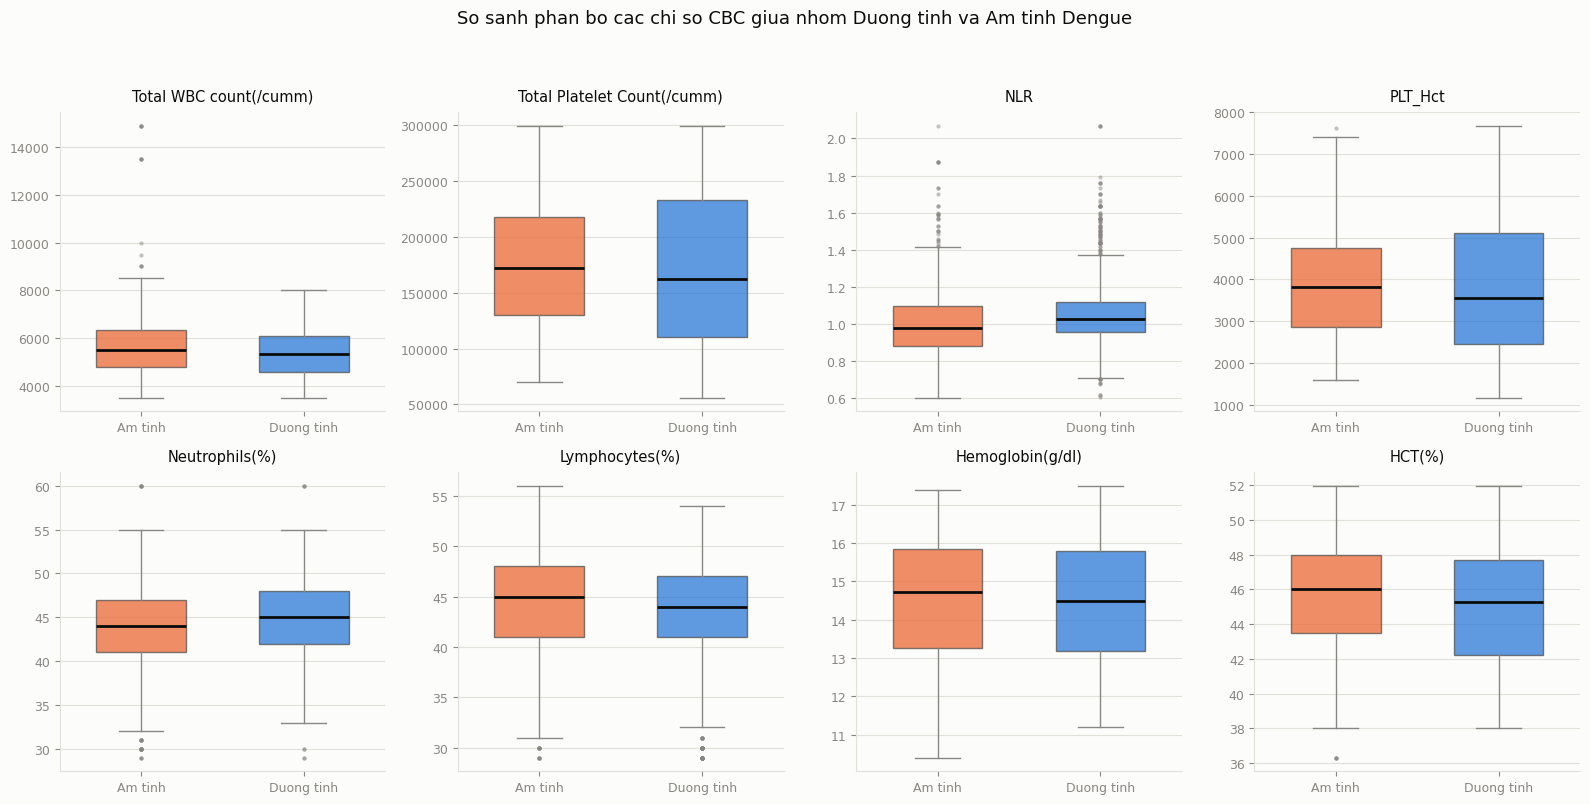

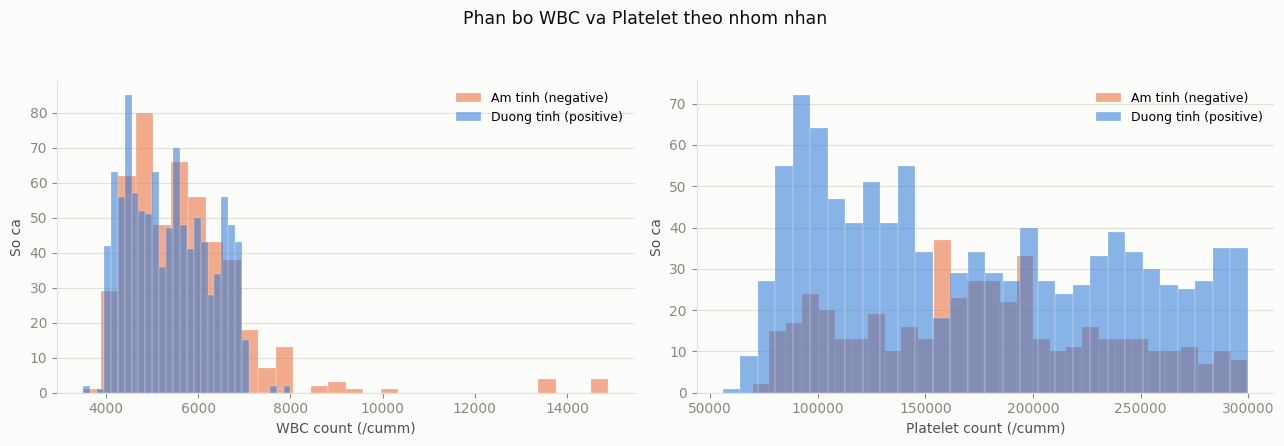

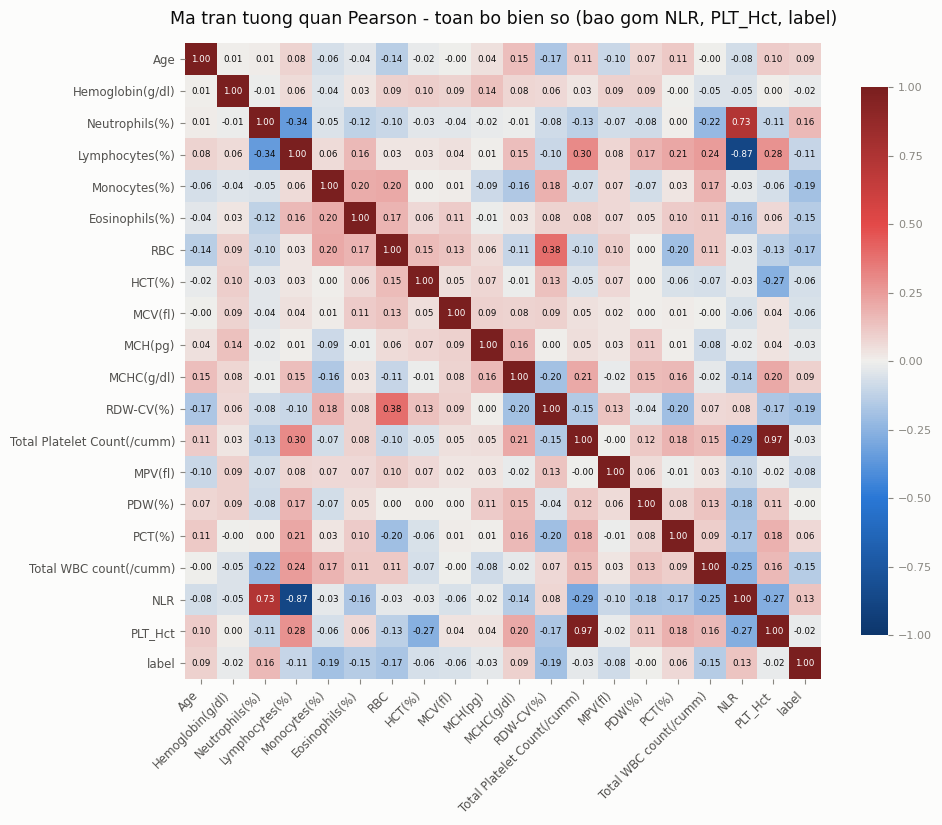

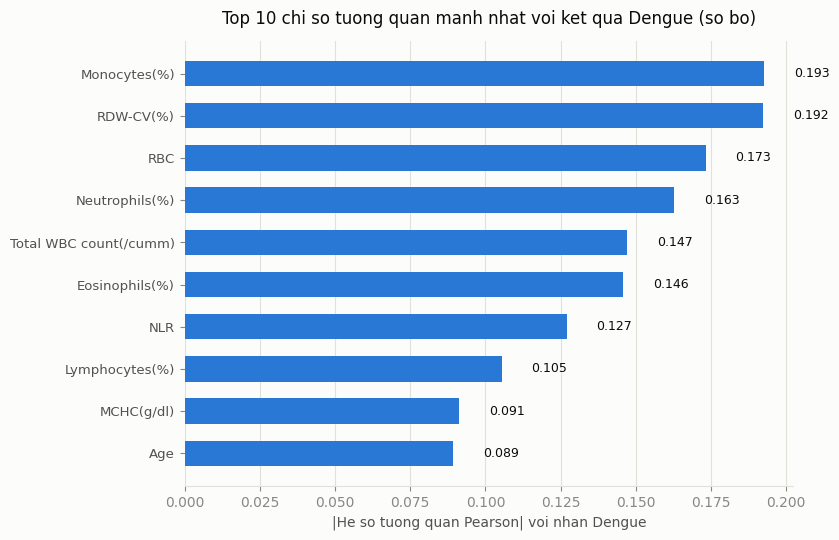


=== Top 10 |correlation| voi label ===
Monocytes(%)              0.1927
RDW-CV(%)                 0.1923
RBC                       0.1732
Neutrophils(%)            0.1626
Total WBC count(/cumm)    0.1470
Eosinophils(%)            0.1457
NLR                       0.1270
Lymphocytes(%)            0.1054
MCHC(g/dl)                0.0912
Age                       0.0893
Name: label, dtype: float64


In [2]:
# -*- coding: utf-8 -*-
"""
Sốt xuất huyết

EDA truc quan - de tai NCKH Dengue (Dengue Fever Hematological Dataset, Mendeley DOI 10.17632/6fsrsk3mb8.2)
Ban Kaggle: tu dong nhan dien file da upload, tu lam sach (loai trung lap) va
tu tinh NLR/PLT_Hct neu file upload la ban goc chua co 2 cot nay.
Chi can chay tuan tu tung cell (da chia bang cac dong "# %%").
"""

# %% [1] Cai dat & tim file input
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Kaggle: moi dataset upload nam trong /kaggle/input/<ten-dataset>/
# Doan duoi day tu dong tim file .csv co chua "Dengue" hoac "Hematological" trong ten,
# neu khong tim thay hay tu sua DATA_PATH thanh duong dan chinh xac (xem panel ben phai
# notebook Kaggle, muc "Input" -> click chuot phai vao file -> "Copy file path").
candidates = glob.glob("Dengue_dataset_FINAL_clean.csv", recursive=True)
candidates = [c for c in candidates if ("dengue" in c.lower() or "hematolog" in c.lower())]
print("Cac file CSV tim thay:")
for c in candidates:
    print(" -", c)

DATA_PATH = candidates[0] if candidates else "/kaggle/input/DOI-SUA-DUONG-DAN-O-DAY.csv"
print("\nSe doc file:", DATA_PATH)

# %% [2] Doc du lieu, tu dong lam sach + tinh NLR/PLT_Hct neu can
df = pd.read_csv(DATA_PATH)
print("Kich thuoc ban dau:", df.shape)

# Chuan hoa ten nhan (Result: positive/negative)
df['Result'] = df['Result'].astype(str).str.strip().str.lower()
df['label'] = (df['Result'] == 'positive').astype(int)

# Loai dong trung lap hoan toan (bo qua NLR/PLT_Hct khi so sanh, vi 2 cot nay
# co the co hoac chua co tuy ban file da upload)
base_cols = [c for c in df.columns if c not in ('NLR', 'PLT_Hct')]
n_before = len(df)
df = df.drop_duplicates(subset=base_cols).reset_index(drop=True)
print(f"Da loai {n_before - len(df)} dong trung lap -> con {len(df)} dong")

# Tinh NLR va PLT_Hct neu file upload la ban goc chua co san
if 'NLR' not in df.columns:
    df['NLR'] = df['Neutrophils(%)'] / df['Lymphocytes(%)']
if 'PLT_Hct' not in df.columns:
    df['PLT_Hct'] = df['Total Platelet Count(/cumm)'] / df['HCT(%)']

print("\nPhan bo nhan:")
print(df['Result'].value_counts())

# %% [3] Bang palette mau (validated colorblind-safe)
BLUE = "#2a78d6"     # duong tinh
ORANGE = "#eb6834"   # am tinh
INK = "#0b0b0b"
INK_SEC = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SEC,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
})

label_names = {0: "Am tinh (negative)", 1: "Duong tinh (positive)"}
colors = {0: ORANGE, 1: BLUE}

# %% [4] FIG 1 - Boxplot 8 chi so CBC chinh theo nhan
features = [
    "Total WBC count(/cumm)", "Total Platelet Count(/cumm)",
    "NLR", "PLT_Hct",
    "Neutrophils(%)", "Lymphocytes(%)",
    "Hemoglobin(g/dl)", "HCT(%)",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    ax = axes[i]
    data0 = df.loc[df['label'] == 0, feat].dropna()
    data1 = df.loc[df['label'] == 1, feat].dropna()
    bp = ax.boxplot(
        [data0, data1], tick_labels=["Am tinh", "Duong tinh"],
        patch_artist=True, widths=0.55,
        flierprops=dict(marker='o', markersize=3, markerfacecolor=MUTED,
                         markeredgecolor='none', alpha=0.5),
        medianprops=dict(color=INK, linewidth=2),
        whiskerprops=dict(color=MUTED, linewidth=1),
        capprops=dict(color=MUTED, linewidth=1),
        boxprops=dict(linewidth=1, edgecolor=INK_SEC),
    )
    for patch, c in zip(bp['boxes'], [ORANGE, BLUE]):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_title(feat, fontsize=10.5, color=INK, pad=8)
    ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(axis='both', labelsize=9)

fig.suptitle("So sanh phan bo cac chi so CBC giua nhom Duong tinh va Am tinh Dengue",
             fontsize=13, color=INK, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# %% [5] FIG 2 - Histogram overlay: WBC va Platelet
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, feat, xlabel in zip(
    axes,
    ["Total WBC count(/cumm)", "Total Platelet Count(/cumm)"],
    ["WBC count (/cumm)", "Platelet count (/cumm)"],
):
    for lbl in [0, 1]:
        vals = df.loc[df['label'] == lbl, feat].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=colors[lbl],
                 label=label_names[lbl], edgecolor='white', linewidth=0.3)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("So ca", fontsize=10)
    ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Phan bo WBC va Platelet theo nhom nhan", fontsize=12.5, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# %% [6] FIG 3 - Heatmap tuong quan Pearson
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'label' not in numeric_cols:
    numeric_cols.append('label')
corr = df[numeric_cols].corr(method='pearson')

diverging_cmap = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#7a1f1f"]
)

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8.5, color=INK_SEC)
ax.set_yticklabels(numeric_cols, fontsize=8.5, color=INK_SEC)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr.values[i, j]
        txtcolor = "white" if abs(v) > 0.55 else INK
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6.3, color=txtcolor)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)
ax.set_title("Ma tran tuong quan Pearson - toan bo bien so (bao gom NLR, PLT_Hct, label)",
             fontsize=12.5, color=INK, pad=14)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

# %% [7] FIG 4 - Top 10 |correlation| voi label
corr_with_label = corr['label'].drop('label').abs().sort_values(ascending=False)
top10 = corr_with_label.head(10)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
y_pos = np.arange(len(top10))
ax.barh(y_pos, top10.values, color=BLUE, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(top10.index, fontsize=9.5, color=INK_SEC)
ax.invert_yaxis()
ax.set_xlabel("|He so tuong quan Pearson| voi nhan Dengue", fontsize=10)
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
for i, v in enumerate(top10.values):
    ax.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=9, color=INK)
ax.set_title("Top 10 chi so tuong quan manh nhat voi ket qua Dengue (so bo)",
             fontsize=12, color=INK, pad=12)
fig.tight_layout()
plt.show()

print("\n=== Top 10 |correlation| voi label ===")
print(top10.round(4))   


In [3]:
# -*- coding: utf-8 -*-
"""
Baseline rule-based model - de tai NCKH Dengue (Dengue Fever Hematological Dataset)
Muc dich: co mot moc so sanh "khong can ML" truoc khi vao Giai doan 2 (train
Logistic Regression / Random Forest / XGBoost). Neu 3 mo hinh ML sau nay khong
vuot duoc baseline nay ro ret, can xem lai.

QUAN TRONG: dung chung random_state=42 va ty le 80/20 o day cho ca luc train
model ML sau nay, de so sanh cong bang tren CUNG mot tap test.
"""

# %% [1] Doc du lieu, lam sach (giong het buoc EDA truoc)
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score)

candidates = glob.glob("Dengue_dataset_FINAL_clean.csv", recursive=True)
candidates = [c for c in candidates if ("dengue" in c.lower() or "hematolog" in c.lower())]
DATA_PATH = candidates[0] if candidates else "/kaggle/input/DOI-SUA-DUONG-DAN-O-DAY.csv"
print("Doc file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df['Result'] = df['Result'].astype(str).str.strip().str.lower()
df['label'] = (df['Result'] == 'positive').astype(int)

base_cols = [c for c in df.columns if c not in ('NLR', 'PLT_Hct')]
df = df.drop_duplicates(subset=base_cols).reset_index(drop=True)

if 'NLR' not in df.columns:
    df['NLR'] = df['Neutrophils(%)'] / df['Lymphocytes(%)']
if 'PLT_Hct' not in df.columns:
    df['PLT_Hct'] = df['Total Platelet Count(/cumm)'] / df['HCT(%)']

print("So dong sau lam sach:", len(df))

# %% [2] Chia train/test 80/20 - CO DINH random_state=42 (dung lai cho model ML sau)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Train: {len(train_df)} ca | Test: {len(test_df)} ca")
print("Ty le duong tinh trong test:", round(test_df['label'].mean(), 3))

y_test = test_df['label'].values


def evaluate(name, y_pred, y_score=None):
    """In bang danh gia: accuracy, precision, recall (uu tien cho bai toan sang loc), f1."""
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}  <-- quan trong nhat cho bai toan sang loc (khong bo sot ca)")
    print(f"F1-score : {f1:.4f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    if y_score is not None:
        try:
            auc = roc_auc_score(y_test, y_score)
            print(f"AUC      : {auc:.4f}")
        except ValueError:
            pass
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


results = []

# %% [3] Baseline A - Luat lam sang kinh dien (khong tune, lay tu y van)
# WHO/y van pho bien: bach cau giam (leukopenia) la dau hieu canh bao Dengue.
# Nguong kinh dien hay dung: WBC < 4000 /cumm
WBC_THRESHOLD_CLINICAL = 4000
pred_a = (test_df['Total WBC count(/cumm)'] < WBC_THRESHOLD_CLINICAL).astype(int).values
results.append(evaluate(
    f"Baseline A - Luat lam sang co dinh (WBC < {WBC_THRESHOLD_CLINICAL})",
    pred_a
))

# %% [4] Baseline B - Nguong toi uu tren tap TRAIN (data-driven, 1 bien WBC)
# Quet toan bo nguong co the, chon nguong cho accuracy cao nhat TREN TRAIN,
# roi moi ap dung sang TEST (dung quy trinh, tranh nhin truoc tap test).
wbc_train = train_df['Total WBC count(/cumm)'].values
y_train = train_df['label'].values

best_thr, best_acc = None, -1
for thr in np.percentile(wbc_train, np.arange(1, 100, 1)):
    pred = (wbc_train < thr).astype(int)
    acc = accuracy_score(y_train, pred)
    if acc > best_acc:
        best_acc, best_thr = acc, thr

print(f"\n[Baseline B] Nguong WBC toi uu tren TRAIN: {best_thr:.0f} (accuracy tren train = {best_acc:.4f})")
pred_b = (test_df['Total WBC count(/cumm)'] < best_thr).astype(int).values
results.append(evaluate(
    f"Baseline B - Nguong WBC toi uu tu train (< {best_thr:.0f})",
    pred_b
))

# %% [5] Baseline C - Ket hop 2 chi so (WBC thap HOAC Platelet thap), nguong tu train
plt_train = train_df['Total Platelet Count(/cumm)'].values

best_combo, best_acc_c = None, -1
for thr_wbc in np.percentile(wbc_train, np.arange(10, 91, 10)):
    for thr_plt in np.percentile(plt_train, np.arange(10, 91, 10)):
        pred = ((wbc_train < thr_wbc) | (plt_train < thr_plt)).astype(int)
        acc = accuracy_score(y_train, pred)
        if acc > best_acc_c:
            best_acc_c, best_combo = acc, (thr_wbc, thr_plt)

thr_wbc_c, thr_plt_c = best_combo
print(f"\n[Baseline C] Nguong toi uu tu train: WBC<{thr_wbc_c:.0f} HOAC Platelet<{thr_plt_c:.0f} "
      f"(accuracy tren train = {best_acc_c:.4f})")
pred_c = ((test_df['Total WBC count(/cumm)'] < thr_wbc_c) |
          (test_df['Total Platelet Count(/cumm)'] < thr_plt_c)).astype(int).values
results.append(evaluate(
    f"Baseline C - WBC<{thr_wbc_c:.0f} HOAC Platelet<{thr_plt_c:.0f} (tu train)",
    pred_c
))

# %% [6] Bang tong hop - day la moc de doi chieu voi LR/RF/XGBoost o Giai doan 2
summary = pd.DataFrame(results).set_index("name").round(4)
print("\n" + "=" * 70)
print("BANG TONG HOP BASELINE (luu lai de so sanh voi LR/RF/XGBoost sau nay)")
print("=" * 70)
print(summary)


Doc file: Dengue_dataset_FINAL_clean.csv
So dong sau lam sach: 1511
Train: 1208 ca | Test: 303 ca
Ty le duong tinh trong test: 0.686

--- Baseline A - Luat lam sang co dinh (WBC < 4000) ---
Accuracy : 0.3135
Precision: 0.0000
Recall   : 0.0000  <-- quan trong nhat cho bai toan sang loc (khong bo sot ca)
F1-score : 0.0000
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 95   0]
 [208   0]]

[Baseline B] Nguong WBC toi uu tren TRAIN: 7000 (accuracy tren train = 0.7111)

--- Baseline B - Nguong WBC toi uu tu train (< 7000) ---
Accuracy : 0.7096
Precision: 0.7041
Recall   : 0.9952  <-- quan trong nhat cho bai toan sang loc (khong bo sot ca)
F1-score : 0.8247
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[  8  87]
 [  1 207]]

[Baseline C] Nguong toi uu tu train: WBC<6770 HOAC Platelet<145000 (accuracy tren train = 0.6854)

--- Baseline C - WBC<6770 HOAC Platelet<145000 (tu train) ---
Accuracy : 0.6997
Precision: 0.7024
Recall   : 0.9760  <-- quan trong nhat cho bai toan sang loc (khong bo sot ca)
F

In [4]:
# -*- coding: utf-8 -*-
"""
Giai doan 2 - Train va so sanh 3 mo hinh: Logistic Regression, Random Forest, XGBoost
De tai NCKH Dengue - Dengue Fever Hematological Dataset (Mendeley DOI 10.17632/6fsrsk3mb8.2)

Dung LAI dung train/test split (random_state=42, 80/20, stratify) va ham
evaluate() giong het buoc baseline, de so sanh cong bang.
"""

# %% [1] Doc du lieu, lam sach (giong het EDA + baseline)
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score)

candidates = glob.glob("Dengue_dataset_FINAL_clean.csv", recursive=True)
candidates = [c for c in candidates if ("dengue" in c.lower() or "hematolog" in c.lower())]
DATA_PATH = candidates[0] if candidates else "/kaggle/input/DOI-SUA-DUONG-DAN-O-DAY.csv"
print("Doc file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df['Result'] = df['Result'].astype(str).str.strip().str.lower()
df['label'] = (df['Result'] == 'positive').astype(int)

base_cols = [c for c in df.columns if c not in ('NLR', 'PLT_Hct')]
df = df.drop_duplicates(subset=base_cols).reset_index(drop=True)

if 'NLR' not in df.columns:
    df['NLR'] = df['Neutrophils(%)'] / df['Lymphocytes(%)']
if 'PLT_Hct' not in df.columns:
    df['PLT_Hct'] = df['Total Platelet Count(/cumm)'] / df['HCT(%)']

# Ma hoa Gender (Male/Female) thanh so, vi model can dau vao dang so
df['Gender_male'] = (df['Gender'].astype(str).str.strip().str.lower() == 'male').astype(int)

print("So dong sau lam sach:", len(df))

# %% [2] Chon dac trung (features) - dung TOAN BO chi so CBC + NLR/PLT_Hct + Gender + Age
feature_cols = [
    'Gender_male', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
    'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)', 'MCH(pg)',
    'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)',
    'PDW(%)', 'PCT(%)', 'Total WBC count(/cumm)', 'NLR', 'PLT_Hct',
]

X = df[feature_cols]
y = df['label']

# %% [3] Chia train/test - GIONG HET buoc baseline (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} ca | Test: {len(X_test)} ca")

# Chuan hoa du lieu (chi can cho Logistic Regression; RF/XGBoost khong can)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


def evaluate(name, y_pred, y_score=None):
    """Ham danh gia GIONG HET buoc baseline, de so sanh cong bang."""
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}  <-- quan trong nhat cho bai toan sang loc")
    print(f"F1-score : {f1:.4f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    auc = None
    if y_score is not None:
        try:
            auc = roc_auc_score(y_test, y_score)
            print(f"AUC      : {auc:.4f}")
        except ValueError:
            pass
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "auc": auc}


results = []

# %% [4] Mo hinh 1 - Logistic Regression (class_weight='balanced')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate("Logistic Regression (class_weight=balanced)", pred_lr, proba_lr))

# %% [5] Mo hinh 2 - Random Forest (class_weight='balanced')
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, max_depth=6
)
rf.fit(X_train, y_train)  # RF khong can chuan hoa du lieu
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]
results.append(evaluate("Random Forest (class_weight=balanced)", pred_rf, proba_rf))

# %% [6] Mo hinh 3 - XGBoost (scale_pos_weight thay cho class_weight)
# XGBoost khong co tham so class_weight, dung scale_pos_weight = so ca am / so ca duong
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"\nscale_pos_weight cho XGBoost = {scale_pos_weight:.3f} (= {n_neg} am / {n_pos} duong)")

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]
results.append(evaluate("XGBoost (scale_pos_weight)", pred_xgb, proba_xgb))

# %% [7] Bang tong hop - so sanh voi baseline da lam truoc do
baseline_rows = [
    {"name": "[Baseline A] Luat lam sang co dinh (WBC<4000)", "accuracy": 0.3135,
     "precision": 0.0, "recall": 0.0, "f1": 0.0, "auc": None},
    {"name": "[Baseline B] Nguong WBC toi uu tu train (<7000)", "accuracy": 0.7096,
     "precision": 0.7041, "recall": 0.9952, "f1": 0.8247, "auc": None},
    {"name": "[Baseline C] WBC<6770 HOAC Platelet<145000", "accuracy": 0.6997,
     "precision": 0.7024, "recall": 0.9760, "f1": 0.8169, "auc": None},
]
summary = pd.DataFrame(baseline_rows + results).set_index("name").round(4)
print("\n" + "=" * 78)
print("BANG SO SANH: BASELINE vs 3 MO HINH ML")
print("=" * 78)
print(summary)
print("\n>> Tieu chi dat: Precision phai ro rang > 0.70 VA Recall van > 0.90")

# %% [8] Feature importance - Top 10 chi so quan trong nhat (RF va XGBoost)
imp_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("\n=== Top 10 Feature Importance - Random Forest ===")
print(imp_rf.head(10).round(4))
print("\n=== Top 10 Feature Importance - XGBoost ===")
print(imp_xgb.head(10).round(4))


Doc file: Dengue_dataset_FINAL_clean.csv
So dong sau lam sach: 1511
Train: 1208 ca | Test: 303 ca

--- Logistic Regression (class_weight=balanced) ---
Accuracy : 0.6304
Precision: 0.7376
Recall   : 0.7163  <-- quan trong nhat cho bai toan sang loc
F1-score : 0.7268
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 42  53]
 [ 59 149]]
AUC      : 0.6257

--- Random Forest (class_weight=balanced) ---
Accuracy : 0.7723
Precision: 0.7663
Recall   : 0.9615  <-- quan trong nhat cho bai toan sang loc
F1-score : 0.8529
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 34  61]
 [  8 200]]
AUC      : 0.6317

scale_pos_weight cho XGBoost = 0.461 (= 381 am / 827 duong)

--- XGBoost (scale_pos_weight) ---
Accuracy : 0.7228
Precision: 0.7696
Recall   : 0.8510  <-- quan trong nhat cho bai toan sang loc
F1-score : 0.8082
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 42  53]
 [ 31 177]]
AUC      : 0.6462

BANG SO SANH: BASELINE vs 3 MO HINH ML
                                                 accuracy  precision  reca

In [5]:
# -*- coding: utf-8 -*-
"""
Giai doan 2 (Tuan 8) - K-fold Cross Validation + Grid Search cho Random Forest
(mo hinh tot nhat trong 3 mo hinh da so sanh)
De tai NCKH Dengue - Dengue Fever Hematological Dataset

QUAN TRONG: Grid Search + 5-fold CV chi chay TREN TAP TRAIN (khong dung tap
test) - tranh "nhin truoc" tap test khi chon sieu tham so. Tap test 303 ca
chi dung 1 LAN DUY NHAT o buoc cuoi de bao cao ket qua that.
"""

# %% [1] Doc du lieu, lam sach (giong het cac buoc truoc)
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score)

candidates = glob.glob("Dengue_dataset_FINAL_clean.csv", recursive=True)
candidates = [c for c in candidates if ("dengue" in c.lower() or "hematolog" in c.lower())]
DATA_PATH = candidates[0] if candidates else "/kaggle/input/DOI-SUA-DUONG-DAN-O-DAY.csv"
print("Doc file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df['Result'] = df['Result'].astype(str).str.strip().str.lower()
df['label'] = (df['Result'] == 'positive').astype(int)

base_cols = [c for c in df.columns if c not in ('NLR', 'PLT_Hct')]
df = df.drop_duplicates(subset=base_cols).reset_index(drop=True)

if 'NLR' not in df.columns:
    df['NLR'] = df['Neutrophils(%)'] / df['Lymphocytes(%)']
if 'PLT_Hct' not in df.columns:
    df['PLT_Hct'] = df['Total Platelet Count(/cumm)'] / df['HCT(%)']

df['Gender_male'] = (df['Gender'].astype(str).str.strip().str.lower() == 'male').astype(int)
print("So dong sau lam sach:", len(df))

feature_cols = [
    'Gender_male', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
    'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)', 'MCH(pg)',
    'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)',
    'PDW(%)', 'PCT(%)', 'Total WBC count(/cumm)', 'NLR', 'PLT_Hct',
]
X = df[feature_cols]
y = df['label']

# %% [2] Chia train/test - GIONG HET cac buoc truoc (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} ca | Test: {len(X_test)} ca (giu nguyen, khong dung de tune)")

def evaluate(name, y_pred, y_score=None):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}  <-- quan trong nhat cho bai toan sang loc")
    print(f"F1-score : {f1:.4f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    if y_score is not None:
        try:
            print(f"AUC      : {roc_auc_score(y_test, y_score):.4f}")
        except ValueError:
            pass
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# %% [3] Random Forest "tay" (chua tune) - de doi chieu truoc/sau Grid Search
rf_manual = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight='balanced', random_state=42
)
rf_manual.fit(X_train, y_train)
pred_manual = rf_manual.predict(X_test)
proba_manual = rf_manual.predict_proba(X_test)[:, 1]
result_before = evaluate("Random Forest - THAM SO TAY (n_estimators=300, max_depth=6)",
                          pred_manual, proba_manual)

# %% [4] Grid Search + 5-fold Cross Validation (CHI TREN TAP TRAIN)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}
# 3 x 5 x 3 = 45 to hop, x 5 fold = 225 lan fit -> mat vai phut tren Kaggle CPU

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
    param_grid=param_grid,
    scoring='f1',        # can bang Precision va Recall khi chon tham so
    cv=cv,
    n_jobs=-1,            # chay song song cac to hop tren nhieu CPU
    verbose=1,
)
print("\nDang chay Grid Search (5-fold CV x 45 to hop tham so)... co the mat vai phut")
grid.fit(X_train, y_train)

print("\n=== KET QUA GRID SEARCH ===")
print("Tham so tot nhat:", grid.best_params_)
print(f"F1-score trung binh tren 5-fold CV (tap TRAIN): {grid.best_score_:.4f}")

# %% [5] Danh gia mo hinh TOT NHAT tren tap TEST (chi dung 1 lan duy nhat)
best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)
proba_best = best_rf.predict_proba(X_test)[:, 1]
result_after = evaluate("Random Forest - SAU GRID SEARCH (tham so toi uu)",
                         pred_best, proba_best)

# %% [6] Bang so sanh truoc/sau Grid Search
summary = pd.DataFrame([result_before, result_after]).set_index("name").round(4)
print("\n" + "=" * 78)
print("SO SANH TRUOC / SAU GRID SEARCH (tren cung tap test 303 ca)")
print("=" * 78)
print(summary)

# %% [7] Kiem tra do on dinh - in ra F1 tung fold trong 5-fold CV cua tham so tot nhat
print("\n=== F1-score tung fold (kiem tra do on dinh, ke hoach yeu cau on dinh +-2%) ===")
cv_results = pd.DataFrame(grid.cv_results_)
best_idx = grid.best_index_
fold_scores = [cv_results.loc[best_idx, f'split{i}_test_score'] for i in range(5)]
for i, s in enumerate(fold_scores):
    print(f"  Fold {i+1}: F1 = {s:.4f}")
print(f"  Trung binh: {np.mean(fold_scores):.4f}  |  Do lech chuan: {np.std(fold_scores):.4f}")


Doc file: Dengue_dataset_FINAL_clean.csv
So dong sau lam sach: 1511
Train: 1208 ca | Test: 303 ca (giu nguyen, khong dung de tune)

--- Random Forest - THAM SO TAY (n_estimators=300, max_depth=6) ---
Accuracy : 0.7723
Precision: 0.7663
Recall   : 0.9615  <-- quan trong nhat cho bai toan sang loc
F1-score : 0.8529
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 34  61]
 [  8 200]]
AUC      : 0.6317

Dang chay Grid Search (5-fold CV x 45 to hop tham so)... co the mat vai phut
Fitting 5 folds for each of 45 candidates, totalling 225 fits

=== KET QUA GRID SEARCH ===
Tham so tot nhat: {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 300}
F1-score trung binh tren 5-fold CV (tap TRAIN): 0.8514

--- Random Forest - SAU GRID SEARCH (tham so toi uu) ---
Accuracy : 0.7723
Precision: 0.7663
Recall   : 0.9615  <-- quan trong nhat cho bai toan sang loc
F1-score : 0.8529
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[ 34  61]
 [  8 200]]
AUC      : 0.6317

SO SANH TRUOC / SAU GRID SEARCH (tren cung t

c:\Users\nngoc\Documents\NghienCuuKhoaHoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Doc file: Dengue_dataset_FINAL_clean.csv
Da train xong mo hinh chot.


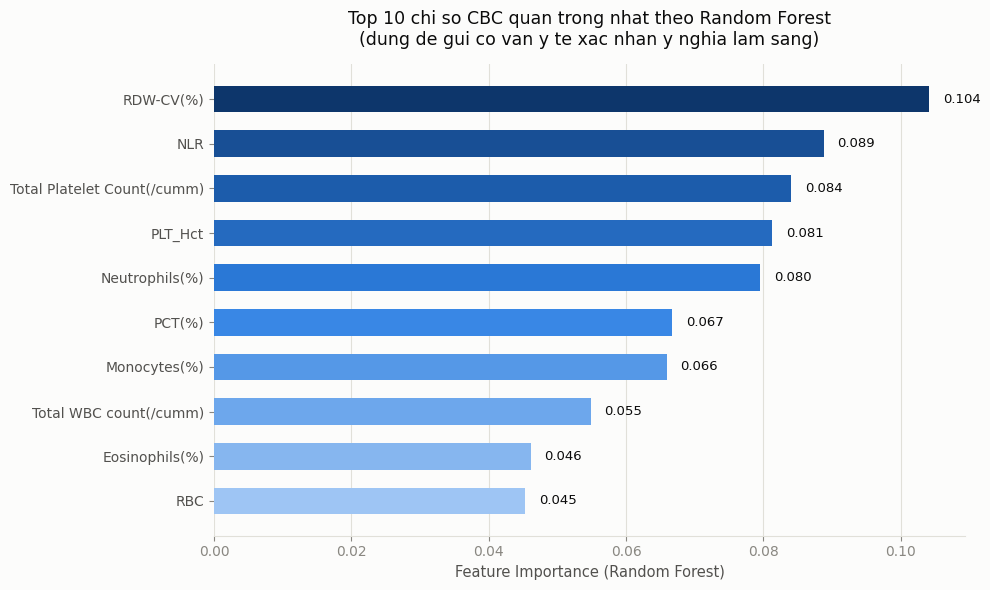


=== Ghi chu lam sang cho Top 5 (dua vao y van, CAN bac si xac nhan lai) ===

* RDW-CV(%) (importance=0.104)
  -> Do phan bo kich thuoc hong cau tang co the phan anh cang thang tuy xuong va thay doi the tich huyet tuong do co dac mau.

* NLR (importance=0.089)
  -> Ty le bach cau trung tinh/lympho tang phan anh phan ung mien dich chuyen dich dien hinh khi co nhiem virus.

* Total Platelet Count(/cumm) (importance=0.084)
  -> Giam tieu cau (thrombocytopenia) la dau hieu kinh dien nhat cua Dengue - virus tan cong tuy xuong va lam tang pha huy tieu cau.

* PLT_Hct (importance=0.081)
  -> Ty le tieu cau/Hct giam phan anh dong thoi giam tieu cau va co dac mau (hemoconcentration) - ca hai deu la dau hieu canh bao Dengue nang.

* Neutrophils(%) (importance=0.080)
  -> Ty le bach cau trung tinh thay doi theo giai doan nhiem virus (giam giai doan dau, co the tang khi co boi nhiem).

Da chon ca so 154 trong tap test de minh hoa SHAP waterfall
Xac suat model du doan duong tinh: 0.789
Ket qua thuc

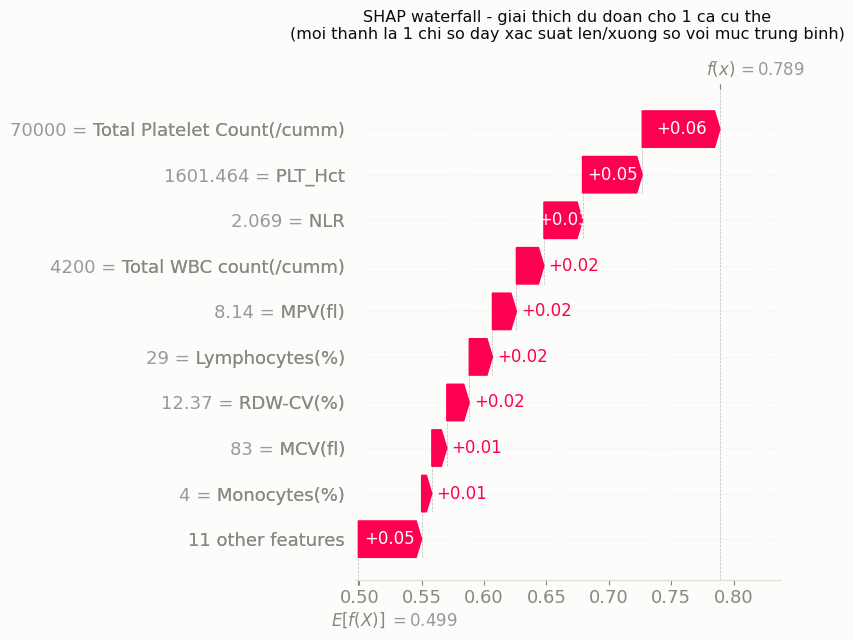


Da luu 2 hinh: fig_feature_importance_top10.png va fig_shap_waterfall_1case.png
Dung 2 hinh nay + bang ghi chu lam sang lam tu lieu gui co van bac si xac nhan.


In [6]:
# -*- coding: utf-8 -*-
"""
Giai doan 2 (Tuan 9) - Feature Importance + SHAP waterfall chart
De tai NCKH Dengue - Dengue Fever Hematological Dataset

Muc dich: tao tu lieu truc quan gui co van y te xac nhan y nghia lam sang
cua cac chi so quan trong nhat. Dung DUNG mo hinh Random Forest da chot
o buoc Grid Search (n_estimators=300, max_depth=6, min_samples_leaf=1).

LUU Y: Kaggle da co san thu vien shap, khong can cai them.
"""

# %% [1] Doc du lieu, lam sach, train lai model CHOT (giong het cac buoc truoc)
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

candidates = glob.glob("Dengue_dataset_FINAL_clean.csv", recursive=True)
candidates = [c for c in candidates if ("dengue" in c.lower() or "hematolog" in c.lower())]
DATA_PATH = candidates[0] if candidates else "/kaggle/input/DOI-SUA-DUONG-DAN-O-DAY.csv"
print("Doc file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df['Result'] = df['Result'].astype(str).str.strip().str.lower()
df['label'] = (df['Result'] == 'positive').astype(int)

base_cols = [c for c in df.columns if c not in ('NLR', 'PLT_Hct')]
df = df.drop_duplicates(subset=base_cols).reset_index(drop=True)

if 'NLR' not in df.columns:
    df['NLR'] = df['Neutrophils(%)'] / df['Lymphocytes(%)']
if 'PLT_Hct' not in df.columns:
    df['PLT_Hct'] = df['Total Platelet Count(/cumm)'] / df['HCT(%)']

df['Gender_male'] = (df['Gender'].astype(str).str.strip().str.lower() == 'male').astype(int)

feature_cols = [
    'Gender_male', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
    'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)', 'MCH(pg)',
    'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)',
    'PDW(%)', 'PCT(%)', 'Total WBC count(/cumm)', 'NLR', 'PLT_Hct',
]
X = df[feature_cols]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mo hinh CHOT tu buoc Grid Search truoc
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=1,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)
print("Da train xong mo hinh chot.")

# %% [2] Bang mo ta lam sang cho top chi so - dua vao y van pho bien ve Dengue
CLINICAL_NOTE = {
    'Total Platelet Count(/cumm)': 'Giam tieu cau (thrombocytopenia) la dau hieu kinh dien nhat cua Dengue - virus tan cong tuy xuong va lam tang pha huy tieu cau.',
    'PLT_Hct': 'Ty le tieu cau/Hct giam phan anh dong thoi giam tieu cau va co dac mau (hemoconcentration) - ca hai deu la dau hieu canh bao Dengue nang.',
    'NLR': 'Ty le bach cau trung tinh/lympho tang phan anh phan ung mien dich chuyen dich dien hinh khi co nhiem virus.',
    'Neutrophils(%)': 'Ty le bach cau trung tinh thay doi theo giai doan nhiem virus (giam giai doan dau, co the tang khi co boi nhiem).',
    'Lymphocytes(%)': 'Tang ty le lympho (kem te bao lympho khong dien hinh) thuong gap trong nhiem virus Dengue giai doan giua.',
    'RDW-CV(%)': 'Do phan bo kich thuoc hong cau tang co the phan anh cang thang tuy xuong va thay doi the tich huyet tuong do co dac mau.',
    'HCT(%)': 'Hematocrit tang la dau hieu co dac mau (plasma leakage) - dau hieu canh bao Dengue nang can theo doi sat.',
    'MPV(fl)': 'The tich tieu cau trung binh tang khi tuy xuong san xuat bu tru tieu cau moi lon hon do tieu cau bi pha huy nhanh.',
    'PCT(%)': 'Plateletcrit (ty le the tich tieu cau/mau) giam dong huong voi giam so luong tieu cau tuyet doi.',
    'Total WBC count(/cumm)': 'Giam bach cau (leukopenia) la dau hieu pho bien nhung khong dac hieu cua nhiem virus noi chung, gom ca Dengue.',
    'Hemoglobin(g/dl)': 'Hemoglobin co the tang nhe do co dac mau, it dac hieu hon Hct.',
    'Age': 'Tuoi anh huong den dap ung mien dich va bieu hien lam sang cua Dengue (tre em/nguoi gia thuong nang hon).',
}

# %% [3] Bang mau (validated colorblind-safe, sequential blue)
BLUE_STEPS = ["#0d366b", "#184f95", "#1c5cab", "#256abf", "#2a78d6",
              "#3987e5", "#5598e7", "#6da7ec", "#86b6ef", "#9ec5f4"]
INK = "#0b0b0b"
INK_SEC = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
})

# %% [4] FIG 1 - Feature Importance toan cuc (top 10), dang bar chart xep hang
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(top10))
colors_bar = BLUE_STEPS[:len(top10)]
ax.barh(y_pos, top10.values, color=colors_bar, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(top10.index, fontsize=10, color=INK_SEC)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Random Forest)", fontsize=10.5)
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
for i, v in enumerate(top10.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9.5, color=INK)
ax.set_title("Top 10 chi so CBC quan trong nhat theo Random Forest\n(dung de gui co van y te xac nhan y nghia lam sang)",
             fontsize=12.5, color=INK, pad=14)
fig.tight_layout()
fig.savefig("fig_feature_importance_top10.png", dpi=180, bbox_inches='tight')
plt.show()

print("\n=== Ghi chu lam sang cho Top 5 (dua vao y van, CAN bac si xac nhan lai) ===")
for feat in top10.head(5).index:
    note = CLINICAL_NOTE.get(feat, "(chua co ghi chu - can tra cuu them)")
    print(f"\n* {feat} (importance={top10[feat]:.3f})")
    print(f"  -> {note}")

# %% [5] FIG 2 - SHAP waterfall cho 1 ca cu the (giai thich "vi sao model doan the nay")
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# shap_values co dang (n_samples, n_features, n_classes) voi RandomForestClassifier
# lay class 1 (duong tinh)
sv_positive = shap_values[..., 1]

# Chon 1 ca: THUC SU duong tinh, model doan dung voi xac suat cao - de minh hoa ro nhat
proba_test = rf.predict_proba(X_test)[:, 1]
true_positive_idx = np.where(y_test.values == 1)[0]
chosen_idx = true_positive_idx[np.argmax(proba_test[true_positive_idx])]

print(f"\nDa chon ca so {chosen_idx} trong tap test de minh hoa SHAP waterfall")
print(f"Xac suat model du doan duong tinh: {proba_test[chosen_idx]:.3f}")
print(f"Ket qua thuc te: {'duong tinh' if y_test.values[chosen_idx]==1 else 'am tinh'}")

fig2 = plt.figure(figsize=(10, 7))
shap.plots.waterfall(sv_positive[chosen_idx], max_display=10, show=False)
plt.title("SHAP waterfall - giai thich du doan cho 1 ca cu the\n"
          "(moi thanh la 1 chi so day xac suat len/xuong so voi muc trung binh)",
          fontsize=11.5, color=INK, pad=14)
plt.tight_layout()
plt.savefig("fig_shap_waterfall_1case.png", dpi=180, bbox_inches='tight')
plt.show()

print("\nDa luu 2 hinh: fig_feature_importance_top10.png va fig_shap_waterfall_1case.png")
print("Dung 2 hinh nay + bang ghi chu lam sang lam tu lieu gui co van bac si xac nhan.")


In [7]:
# %% [10] Lưu 3 model

import os
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lr,  os.path.join(MODEL_DIR, "dengue_logistic_regression.pkl"))
joblib.dump(rf,  os.path.join(MODEL_DIR, "dengue_random_forest.pkl"))
joblib.dump(xgb, os.path.join(MODEL_DIR, "dengue_xgboost.pkl"))

# Lưu feature
joblib.dump(feature_cols, os.path.join(MODEL_DIR, "dengue_features.pkl"))

print("Đã lưu 3 model:")
print("- Logistic Regression")
print("- Random Forest")
print("- XGBoost")

Đã lưu 3 model:
- Logistic Regression
- Random Forest
- XGBoost


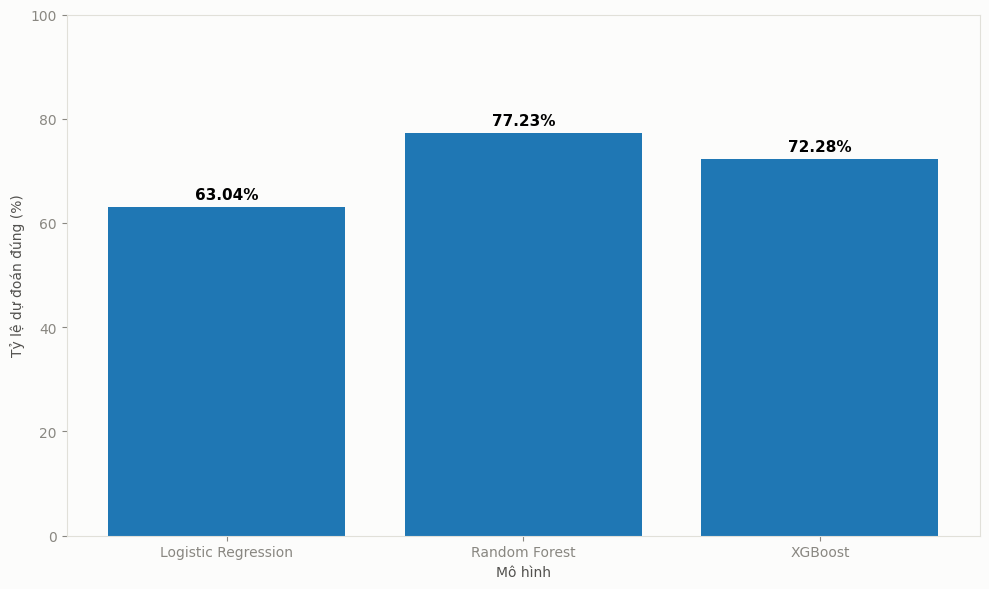

In [8]:
import matplotlib.pyplot as plt

# Lấy Accuracy của 3 mô hình từ results
model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

accuracy_values = [
    results[0]["accuracy"] * 100,
    results[1]["accuracy"] * 100,
    results[2]["accuracy"] * 100
]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    model_names,
    accuracy_values
)

# Hiển thị % trên đầu mỗi cột
for bar, value in zip(bars, accuracy_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


ax.set_xlabel("Mô hình")
ax.set_ylabel("Tỷ lệ dự đoán đúng (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()